In [1]:
packages <- c("ggplot2", "dplyr", "RColorBrewer", "ggpattern", "patchwork")
for (pkg in packages) {
  suppressPackageStartupMessages(
    suppressWarnings(
      library(pkg, character.only = TRUE)
    )
  )
}


In [2]:
figures_path <- file.path("../figures/NF0014/")
# Get the current working directory and find Git root
find_git_root <- function() {
    # Get current working directory
    cwd <- getwd()

    # Check if current directory has .git
    if (dir.exists(file.path(cwd, ".git"))) {
        return(cwd)
    }

    # If not, search parent directories
    current_path <- cwd
    while (dirname(current_path) != current_path) {  # While not at root
        parent_path <- dirname(current_path)
        if (dir.exists(file.path(parent_path, ".git"))) {
            return(parent_path)
        }
        current_path <- parent_path
    }

    # If no Git root found, stop with error
    stop("No Git root directory found.")
}

# Find the Git root directory
root_dir <- find_git_root()

source(file.path(root_dir, "utils/r_plot_themes.r"))
source(file.path(root_dir, "utils/r_plot_funcs.r"))

In [3]:
cell_counts_path_dir <- file.path(root_dir, "1.EDA/results/cell_counts/cell_counts.parquet")
cell_counts_figure_path <- file.path(root_dir, "1.EDA/figures/cell_counts")
if (!dir.exists(cell_counts_figure_path)) {
    dir.create(cell_counts_figure_path, recursive = TRUE)
}
if (!dir.exists(cell_counts_figure_path)) {
    dir.create(cell_counts_figure_path, recursive = TRUE)
}

In [4]:

# read in all the cell counts files and combine them into a single data frame
cell_counts_df <- arrow::read_parquet(cell_counts_path_dir)
dim(cell_counts_df)
# drop the CQ1 data
cell_counts_df <- cell_counts_df %>%
  dplyr::filter(Metadata_Biology_PatientTumor != "NF0037_T1_CQ1")


[1] 12148    11

In [5]:
add_feature_type <- function(df, x) {
    #' Add a column to the input data frame that classifies each profile by feature type.
    #'
    #' This function takes a data frame and adds a new column called `Metadata_feature_type`
    #' that classifies each profile based on the values in the `Metadata_profile_type` column. The classification is done using a series of conditions that check for specific keywords in the `Metadata_profile
    col_vals <- df[[x]]
    df %>%
        mutate(
            Metadata_feature_type = dplyr::case_when(
                # nucleocentric and sammed
                grepl("sammed", col_vals, ignore.case = TRUE) 
                & grepl("nucleocentric", col_vals, ignore.case = TRUE) 
                ~ "Nucleocentric DL (SAMMed3D)",

                grepl("morphem", col_vals, ignore.case = TRUE) 
                & grepl("nucleocentric", col_vals, ignore.case = TRUE) 
                ~ "Nucleocentric DL (MorphEM)",

                grepl("sammed", col_vals, ignore.case = TRUE) 
                & !grepl("nucleocentric", col_vals, ignore.case = TRUE) 
                & grepl("sc", col_vals, ignore.case = TRUE)
                ~ "Sc DL (SAMMed3D)",

                grepl("sammed", col_vals, ignore.case = TRUE) 
                & !grepl("nucleocentric", col_vals, ignore.case = TRUE) 
                & grepl("organoid", col_vals, ignore.case = TRUE)
                ~ "Organoid DL (SAMMed3D)",

                !grepl("sammed", col_vals, ignore.case = TRUE) 
                & !grepl("nucleocentric", col_vals, ignore.case = TRUE) 
                & grepl("3D", col_vals, ignore.case = TRUE) 
                & grepl("sc", col_vals, ignore.case = TRUE)
                ~ "Sc Handcrafted (ZedProfiler)",

                !grepl("sammed", col_vals, ignore.case = TRUE) 
                & !grepl("nucleocentric", col_vals, ignore.case = TRUE) 
                & grepl("3D", col_vals, ignore.case = TRUE) 
                & grepl("organoid", col_vals, ignore.case = TRUE)
                ~ "Organoid Handcrafted (ZedProfiler)",

            

                grepl("2D", col_vals, ignore.case = TRUE) 
                & grepl("max", col_vals, ignore.case = TRUE) 
                & grepl("sc", col_vals, ignore.case = TRUE)
                ~ "Sc 2D Max Projection",
                
                grepl("2D", col_vals, ignore.case = TRUE) 
                & grepl("max", col_vals, ignore.case = TRUE) 
                & grepl("Organoid", col_vals, ignore.case = TRUE)
                ~ "Organoid 2D Max Projection",
                

                grepl("2D", col_vals, ignore.case = TRUE) 
                & grepl("middle_slice", col_vals, ignore.case = TRUE) 
                & grepl("sc", col_vals, ignore.case = TRUE)
                ~ "Sc 2D Middle Slice",
                
                grepl("2D", col_vals, ignore.case = TRUE) 
                & grepl("middle_slice", col_vals, ignore.case = TRUE) 
                & grepl("Organoid", col_vals, ignore.case = TRUE)
                ~ "Organoid 2D Middle Slice",

                grepl("2D", col_vals, ignore.case = TRUE) 
                & grepl("middle_n", col_vals, ignore.case = TRUE) 
                & grepl("sc", col_vals, ignore.case = TRUE)
                ~ "Sc 2D Middle 3 Slices",

                grepl("2D", col_vals, ignore.case = TRUE) 
                & grepl("middle_n", col_vals, ignore.case = TRUE) 
                & grepl("Organoid", col_vals, ignore.case = TRUE)
                ~ "Organoid 2D Middle 3 Slices",
                TRUE ~ "other"
            )
        )
}


cell_counts_df <- add_feature_type(cell_counts_df, "Metadata_profile_name")
cell_counts_df$sc_or_organoid <- "other"
cell_counts_df$sc_or_organoid <- dplyr::case_when(
    grepl("organoid", cell_counts_df$Metadata_profile_name, ignore.case = TRUE) ~ "organoid",
    grepl("(^|_)sc(_|$)", cell_counts_df$Metadata_profile_name, ignore.case = TRUE) ~ "sc",
    grepl("(^|_)nucleocentric(_|$)", cell_counts_df$Metadata_profile_name, ignore.case = TRUE) ~ "nucleocentric",
    TRUE ~ "other"
)

Warning message:
“Removed 344 rows containing non-finite outside the scale range
(`stat_density()`).”
Warning message:
“Removed 40 rows containing non-finite outside the scale range
(`stat_density()`).”
Warning message:
“Removed 42 rows containing non-finite outside the scale range
(`stat_density()`).”
Warning message:
“Removed 344 rows containing non-finite outside the scale range
(`stat_density()`).”
Warning message:
“Removed 40 rows containing non-finite outside the scale range
(`stat_density()`).”
Warning message:
“Removed 42 rows containing non-finite outside the scale range
(`stat_density()`).”


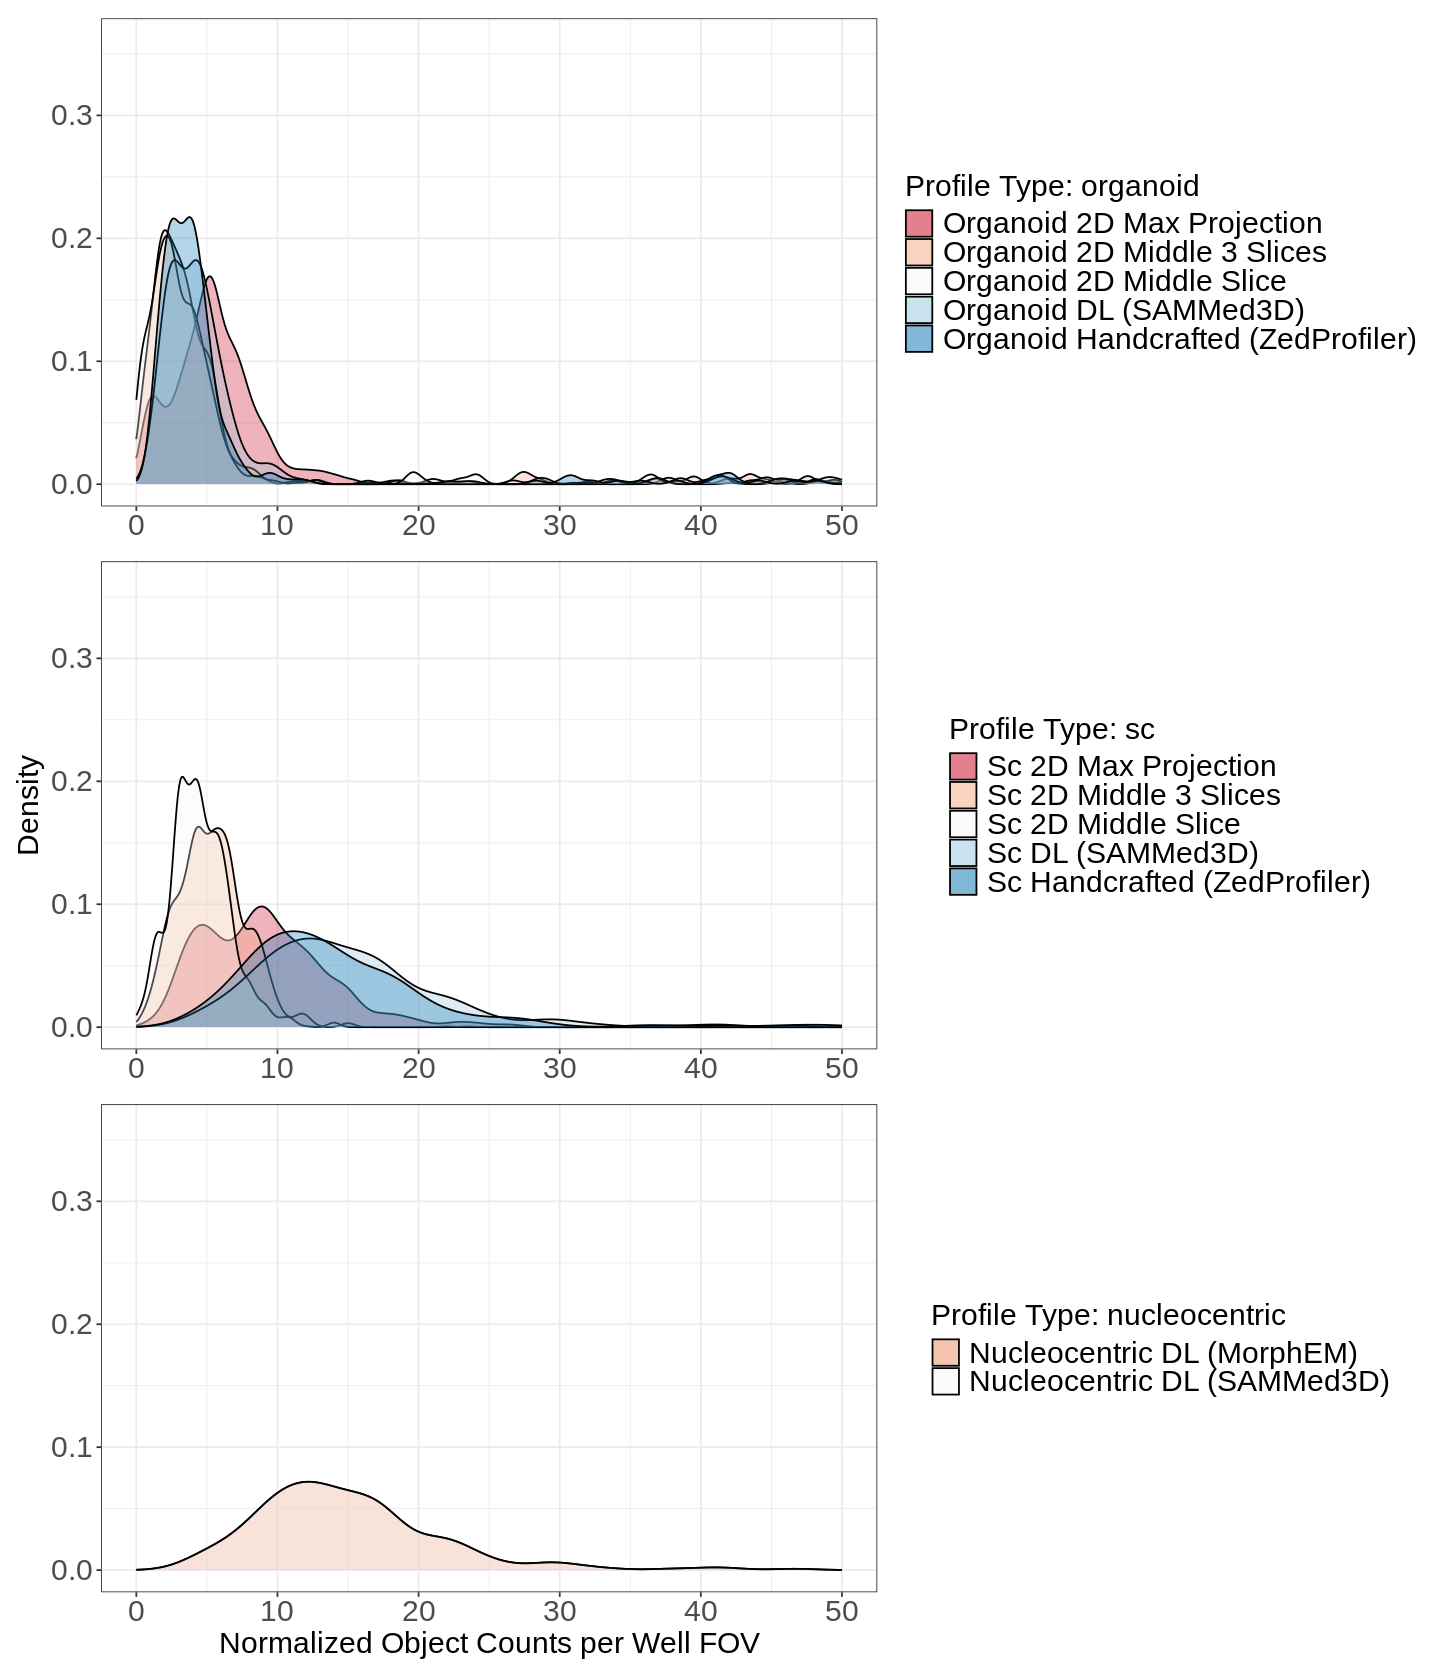

In [6]:
width <- 12
height <- 14
options(repr.plot.width = width, repr.plot.height = height)

# compute the max density across all facet levels so y-axis can be shared
max_density <- cell_counts_df %>%
    filter(!is.na(Metadata_n_cells_norm_by_well_fov)) %>%
    group_by(sc_or_organoid, Metadata_feature_type) %>%
    summarise(
        dens = list(density(Metadata_n_cells_norm_by_well_fov, na.rm = TRUE)$y),
        .groups = "drop"
    ) %>%
    pull(dens) %>%
    unlist() %>%
    max()

facet_levels <- unique(cell_counts_df$sc_or_organoid)

plot_list <- lapply(
    facet_levels,
    function(fv) plot_density_by_facet(
        cell_counts_df,
        facet_col = "sc_or_organoid",
        facet_val = fv,
        x_col = "Metadata_n_cells_norm_by_well_fov",
        fill_col = "Metadata_feature_type",
        y_max = max_density,
        x_max = 50,
    )
)

cell_count_density_plot <- wrap_plots(plot_list, ncol = 1) +
    plot_layout(axis_titles = "collect")
save_ggplot(
    cell_count_density_plot,
    path = file.path(cell_counts_figure_path, "cell_count_density_plot.png"),
    width = width,
    height = height
)

Warning message:
“Removed 638 rows containing non-finite outside the scale range
(`stat_boxplot()`).”
Warning message in RColorBrewer::brewer.pal(n, pal):
“n too large, allowed maximum for palette RdBu is 11
Returning the palette you asked for with that many colors
”
Warning message:
“Removed 638 rows containing non-finite outside the scale range
(`stat_boxplot()`).”
Warning message in RColorBrewer::brewer.pal(n, pal):
“n too large, allowed maximum for palette RdBu is 11
Returning the palette you asked for with that many colors
”


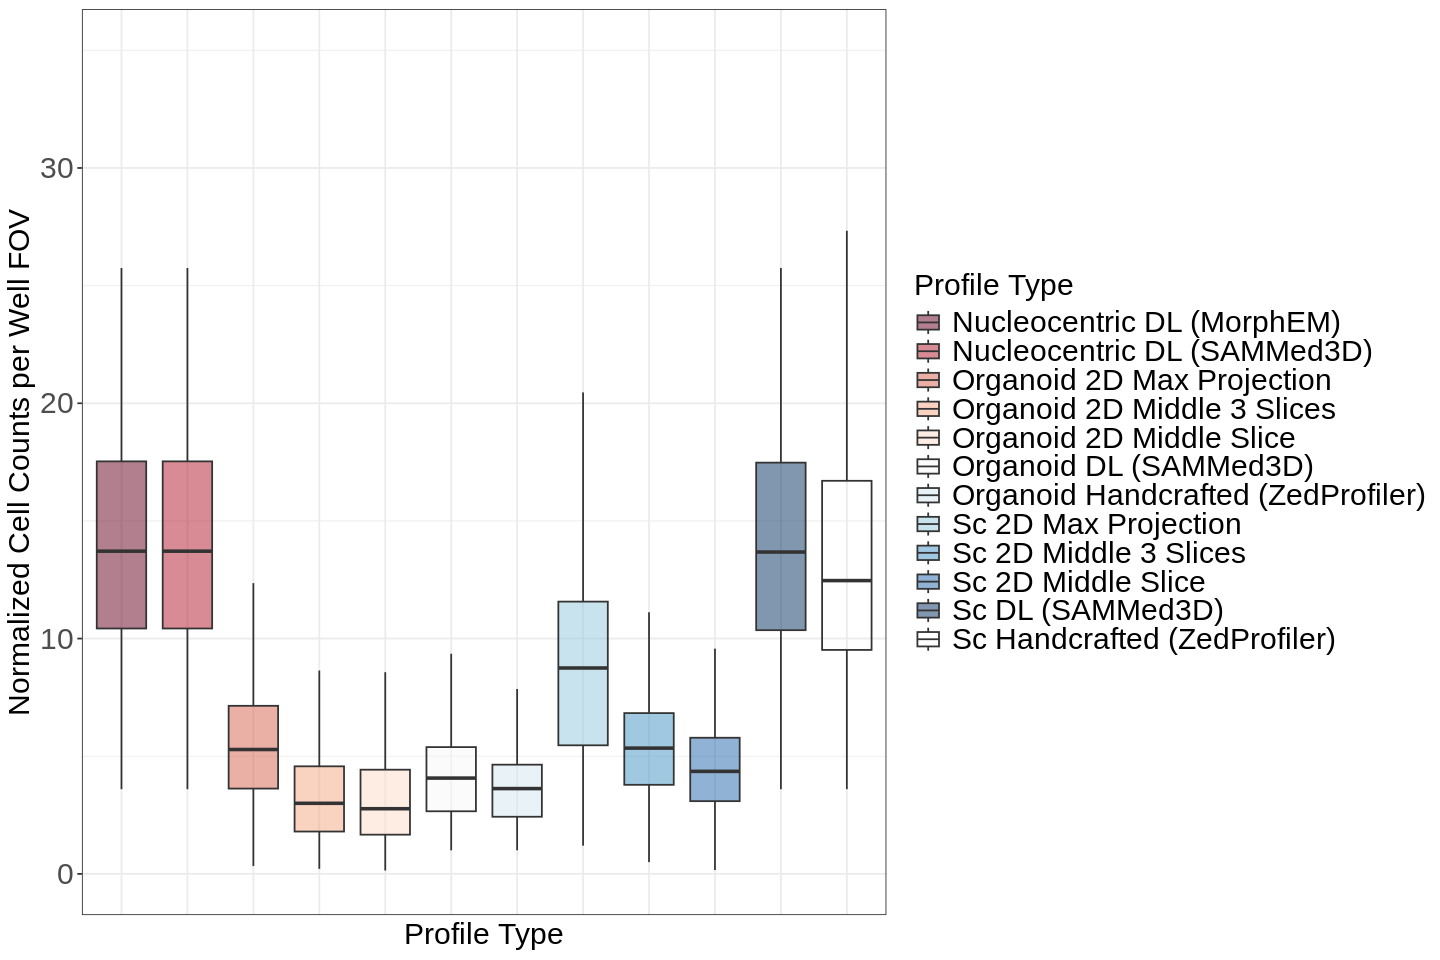

In [7]:
width <- 12
height <- 8
options(repr.plot.width = width, repr.plot.height = height)
# summary_boxplot per feature type and sc_or_organoid
summary_plot <- plot_boxplot(
    cell_counts_df,
    x_col = "Metadata_feature_type",
    y_col = "Metadata_n_cells_norm_by_well_fov",
    fill_col = "Metadata_feature_type",
    x_lab = "Profile Type",
    y_lab = "Normalized Cell Counts per Well FOV",
    fill_lab = "Profile Type",
    ylim_max = 35,
    x_text = "blank"
)
save_ggplot(
    summary_plot,
    path = file.path(cell_counts_figure_path, "cell_count_summary_boxplot.png"),
    width = width,
    height = height
)

In [8]:
# get only thre ZedProfiler profiles 
zedprofiler_only_df <- cell_counts_df %>%
    filter(Metadata_feature_type %in% c("Sc Handcrafted (ZedProfiler)", "Organoid Handcrafted (ZedProfiler)"))

Warning message:
“Removed 21 rows containing non-finite outside the scale range
(`stat_boxplot()`).”
Warning message in RColorBrewer::brewer.pal(n, pal):
“n too large, allowed maximum for palette RdBu is 11
Returning the palette you asked for with that many colors
”
Warning message:
“Removed 21 rows containing non-finite outside the scale range
(`stat_boxplot()`).”
Warning message in RColorBrewer::brewer.pal(n, pal):
“n too large, allowed maximum for palette RdBu is 11
Returning the palette you asked for with that many colors
”


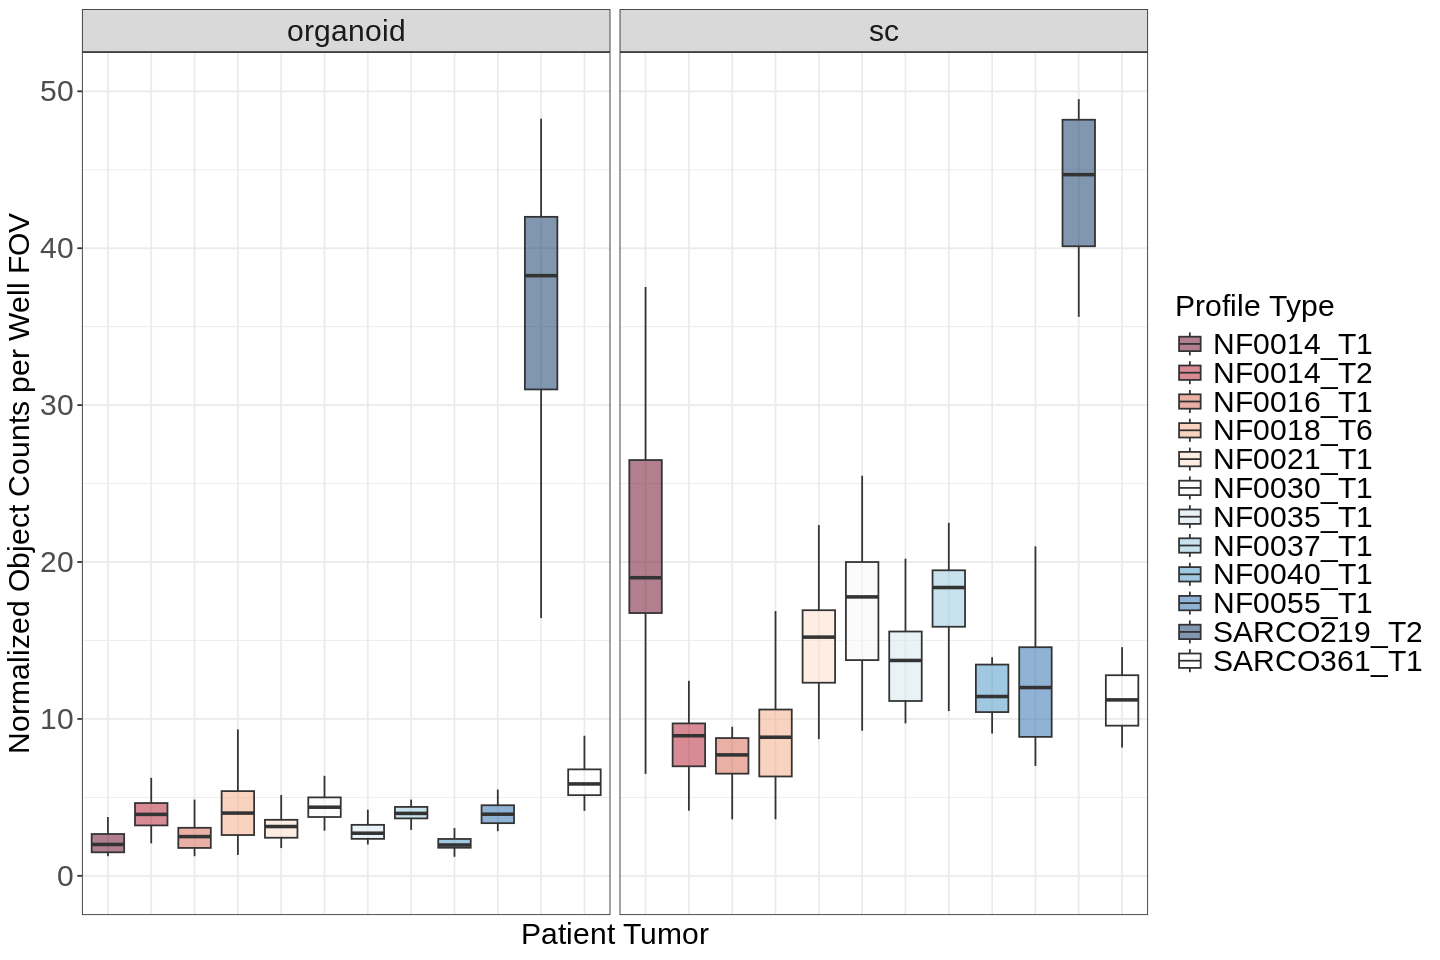

In [9]:
cell_count_per_patient_plot <- plot_boxplot(
    zedprofiler_only_df,
    x_col = "Metadata_Biology_PatientTumor",
    y_col = "Metadata_n_cells_norm_by_well_fov",
    fill_col = "Metadata_Biology_PatientTumor",
    x_lab = "Patient Tumor",
    y_lab = "Normalized Object Counts per Well FOV",
    fill_lab = "Profile Type",
    ylim_max = 50,
    x_text = "blank",
    facet_formula = as.formula(sc_or_organoid ~ .)
)
save_ggplot(
    cell_count_per_patient_plot,
    path = file.path(cell_counts_figure_path, "cell_count_per_patient_boxplot.png"),
    width = width,
    height = height
)

In [10]:
no_nucleocentric_organoid_df <- zedprofiler_only_df %>%
    filter(sc_or_organoid == "organoid")
no_nucleocentric_sc_df <- zedprofiler_only_df %>%
    filter(sc_or_organoid == "sc")

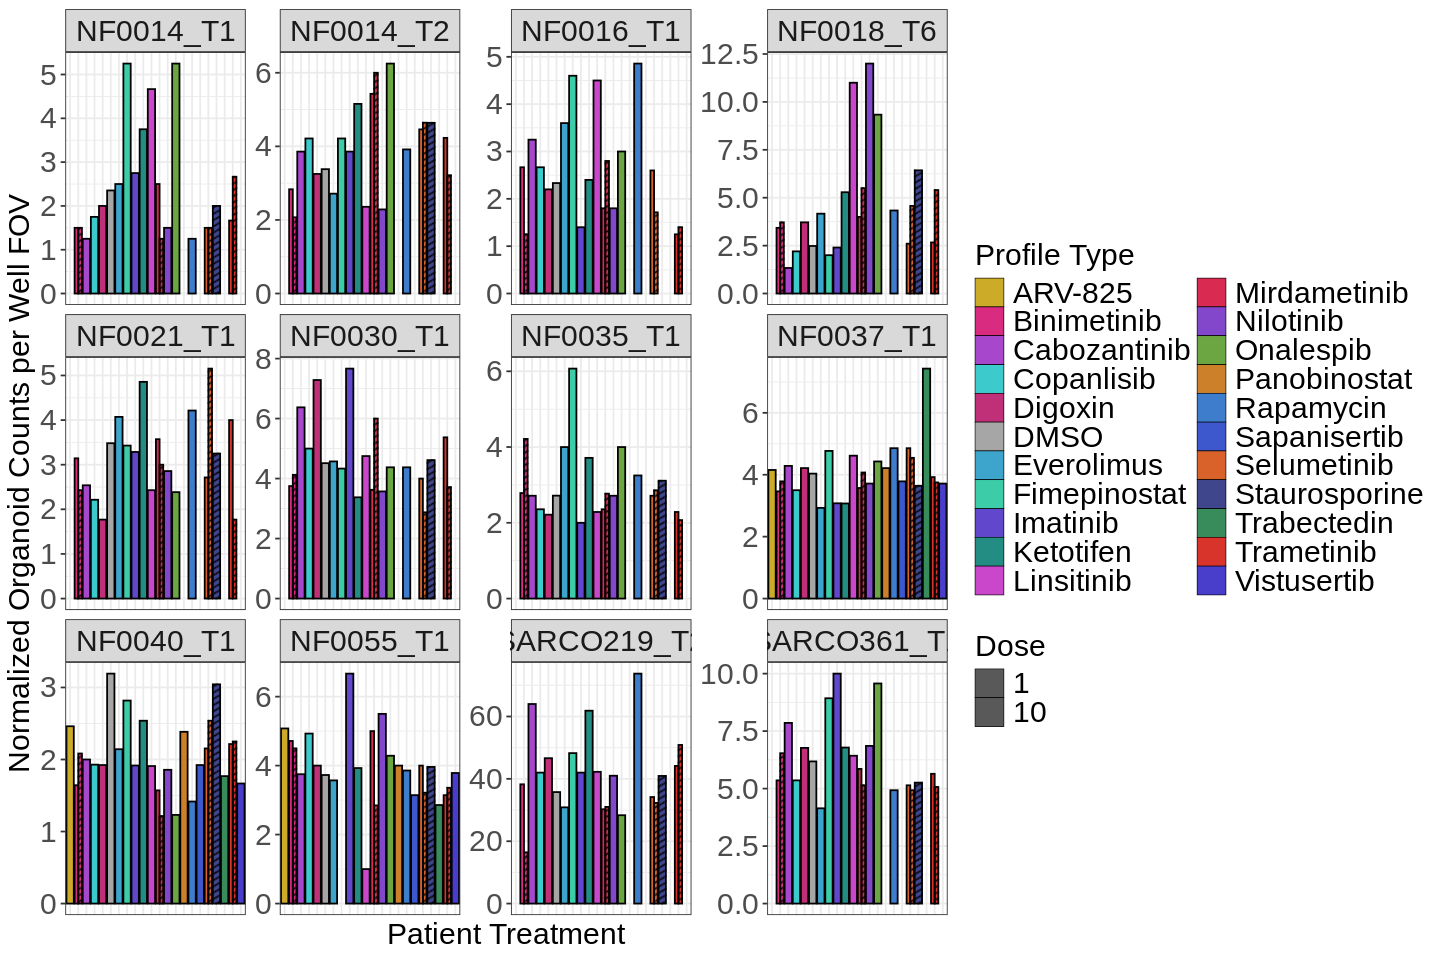

In [11]:
width <- 25
height <- 12
organoid_count_by_treatment_plot <- plot_bar_pattern(
    no_nucleocentric_organoid_df,
    x_col = "Metadata_Experiment_Treatment",
    y_col = "Metadata_n_cells_norm_by_well_fov",
    fill_col = "Metadata_Experiment_Treatment",
    pattern_col = "Metadata_Experiment_Dose",
    fill_palette = custom_treatment_palette,
    x_lab = "Patient Treatment",
    y_lab = "Normalized Organoid Counts per Well FOV",
    x_text = "blank",
    facet_formula = as.formula(. ~ Metadata_Biology_PatientTumor)
)
save_ggplot(
    organoid_count_by_treatment_plot,
    path = file.path(cell_counts_figure_path, "organoid_count_by_treatment_barplot.png"),
    width = width,
    height = height
)

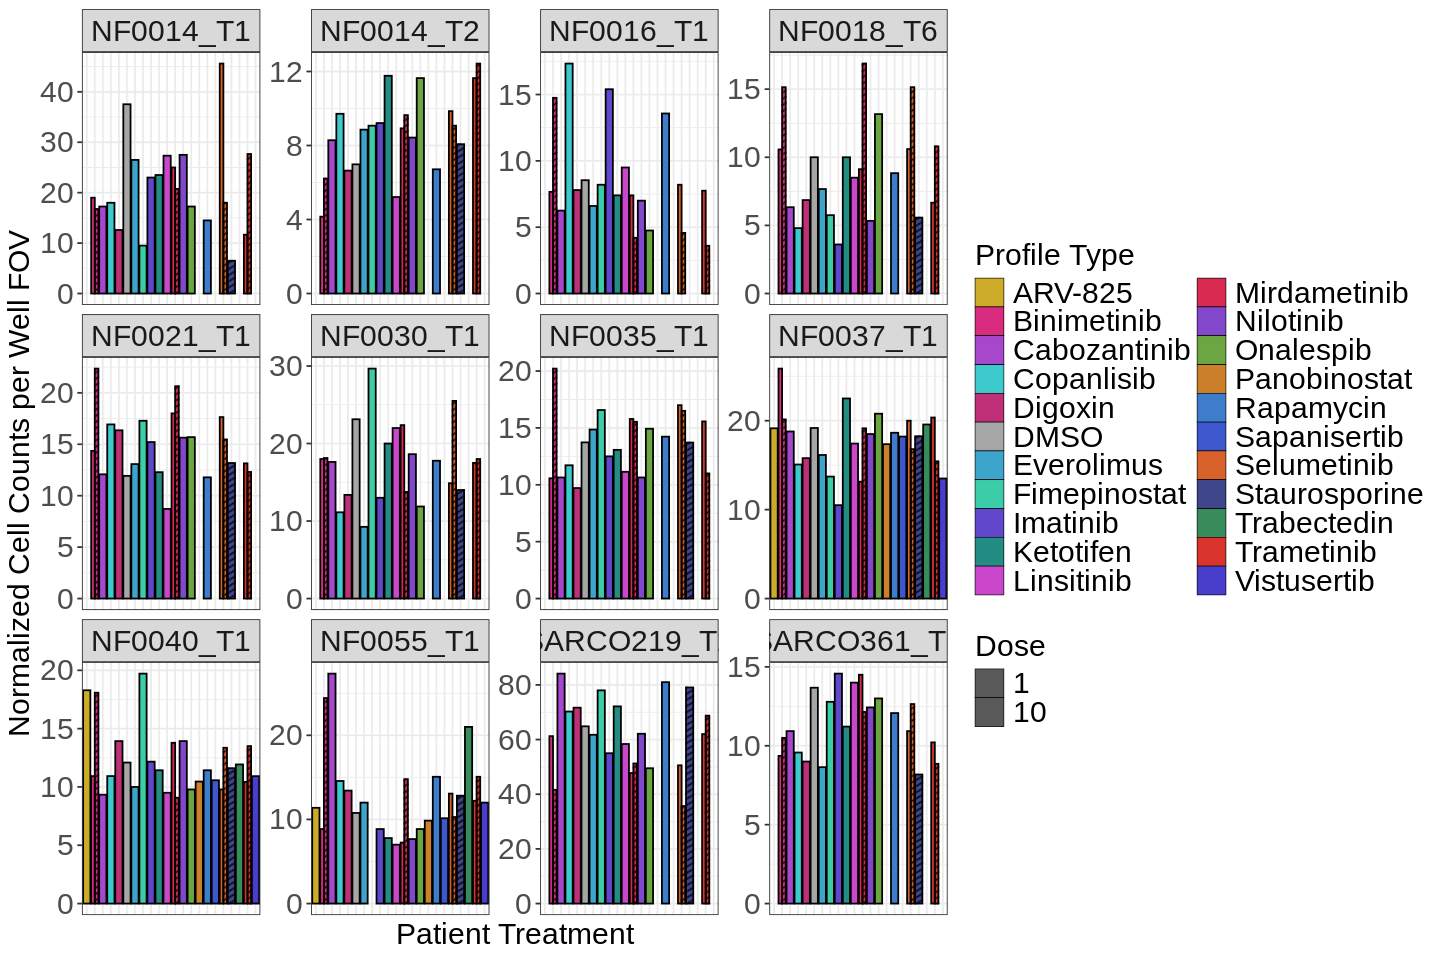

In [12]:
width <- 25
height <- 12
cell_count_by_treatment_plot <- plot_bar_pattern(
    no_nucleocentric_sc_df,
    x_col = "Metadata_Experiment_Treatment",
    y_col = "Metadata_n_cells_norm_by_well_fov",
    fill_col = "Metadata_Experiment_Treatment",
    pattern_col = "Metadata_Experiment_Dose",
    fill_palette = custom_treatment_palette,
    x_lab = "Patient Treatment",
    y_lab = "Normalized Cell Counts per Well FOV",
    x_text = "blank",
    facet_formula = as.formula(. ~ Metadata_Biology_PatientTumor)
)
save_ggplot(
    cell_count_by_treatment_plot,
    path = file.path(cell_counts_figure_path, "cell_count_by_treatment_barplot.png"),
    width = width,
    height = height
)

Warning message:
“Removed 21 rows containing non-finite outside the scale range
(`stat_boxplot()`).”
Warning message:
“Removed 21 rows containing non-finite outside the scale range
(`stat_boxplot()`).”


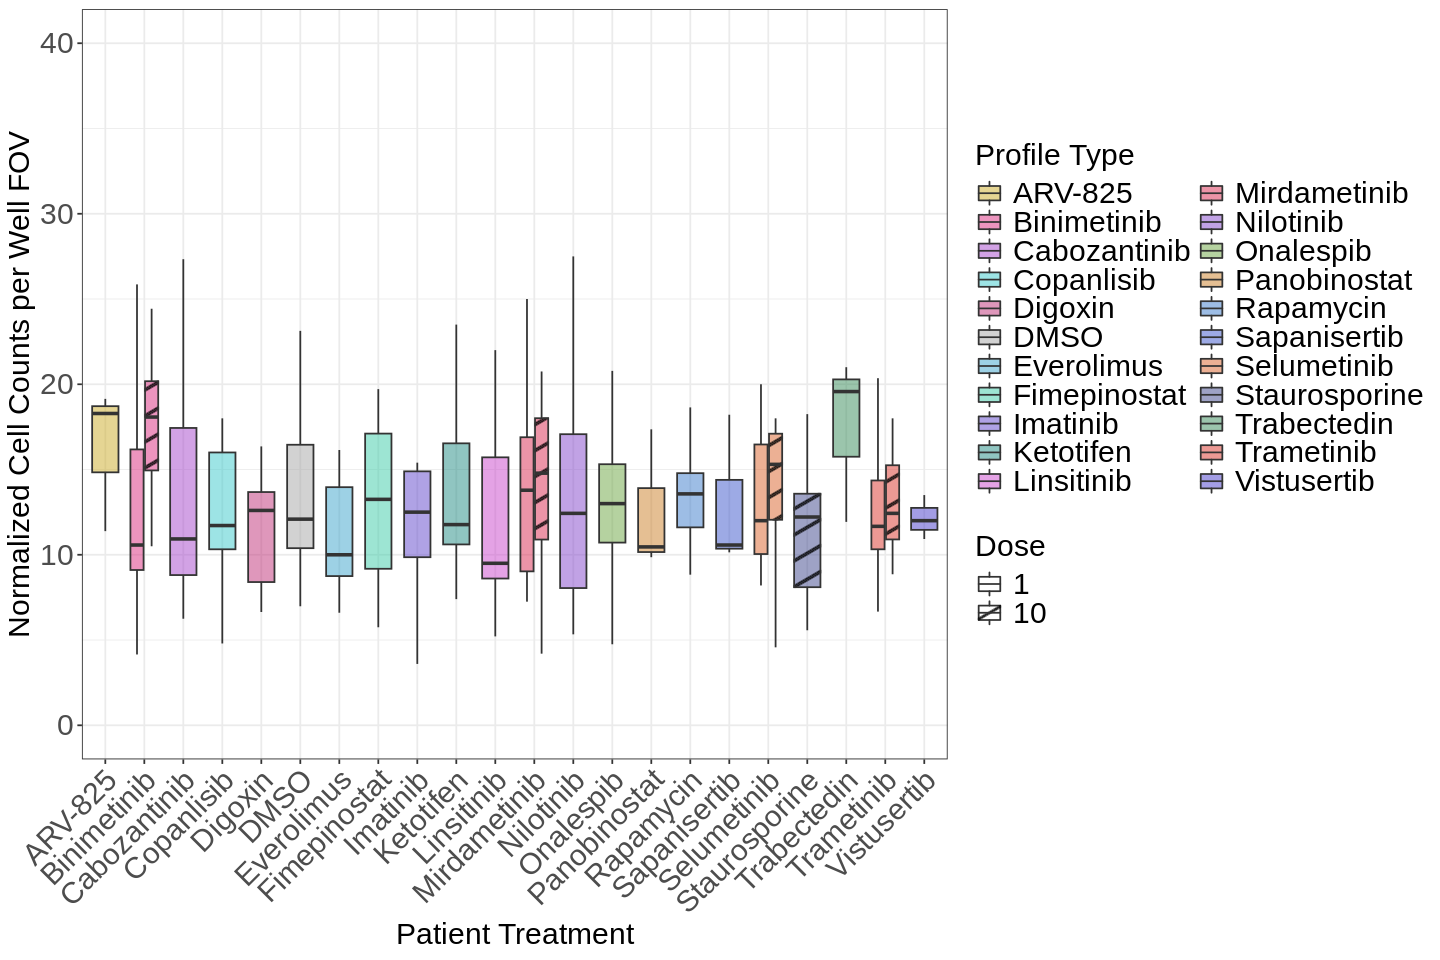

In [13]:
width <- 12
height <- 8
options(repr.plot.width = width, repr.plot.height = height)
cell_count_by_treatment_plot <- plot_boxplot_pattern(
    no_nucleocentric_sc_df,
    x_col = "Metadata_Experiment_Treatment",
    y_col = "Metadata_n_cells_norm_by_well_fov",
    fill_col = "Metadata_Experiment_Treatment",
    pattern_col = "Metadata_Experiment_Dose",
    fill_palette = custom_treatment_palette,
    x_lab = "Patient Treatment",
    y_lab = "Normalized Cell Counts per Well FOV",
    ylim_max = 40,
    x_text = "angled"
)
save_ggplot(
    cell_count_by_treatment_plot,
    path = file.path(cell_counts_figure_path, "cell_count_by_treatment_boxplot.png"),
    width = width,
    height = height
)

Warning message:
“Removed 20 rows containing non-finite outside the scale range
(`stat_boxplot()`).”
Warning message:
“Removed 20 rows containing non-finite outside the scale range
(`stat_boxplot()`).”


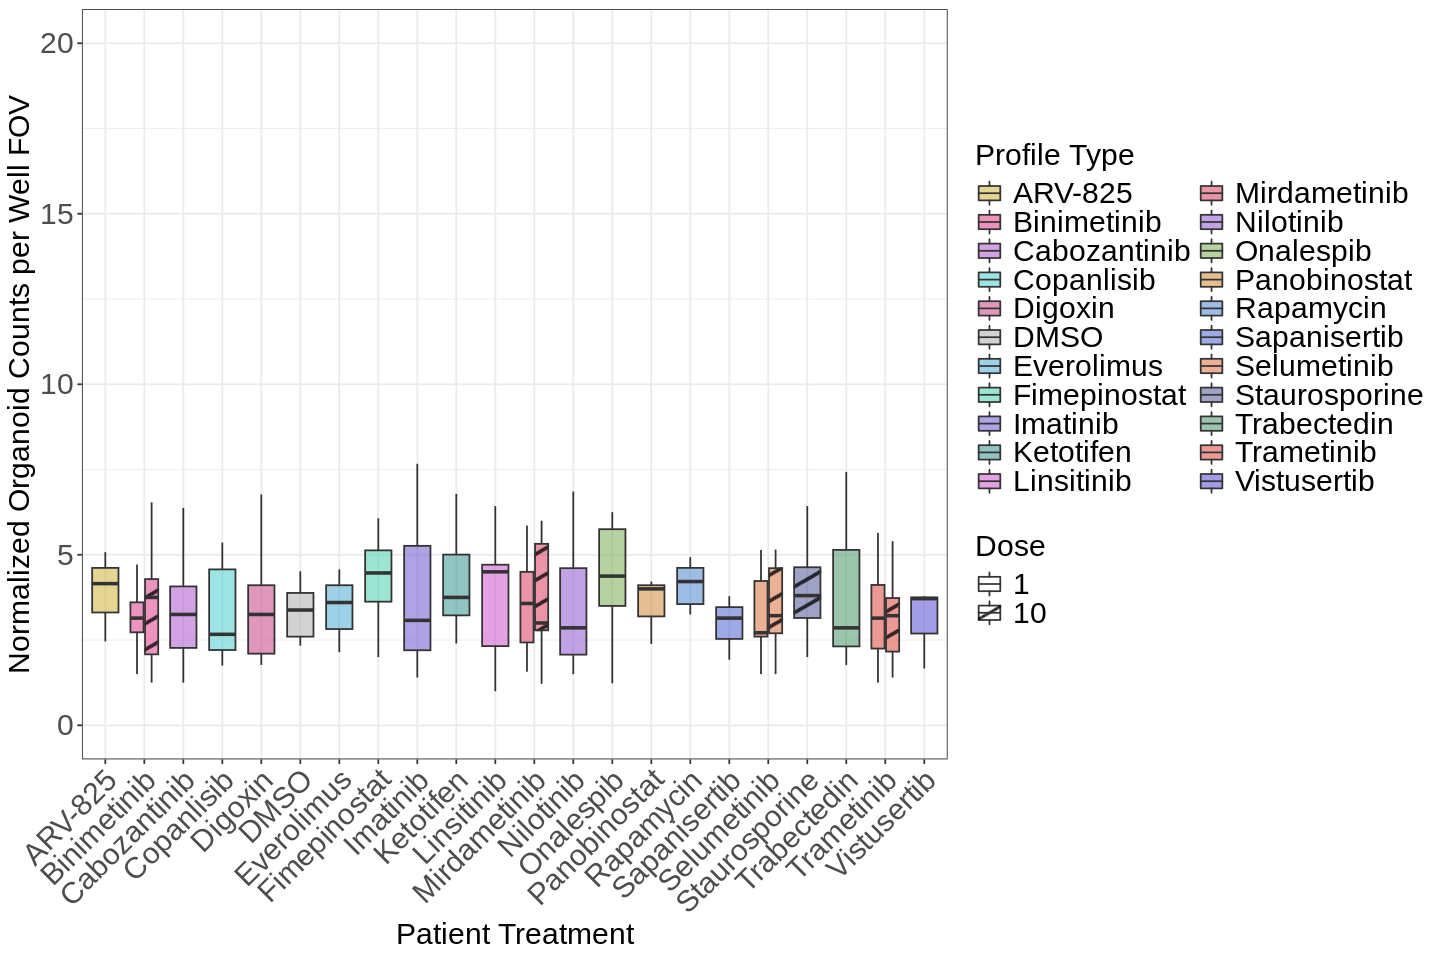

In [14]:
width <- 12
height <- 8
options(repr.plot.width = width, repr.plot.height = height)
organoid_count_by_treatment_plot <- plot_boxplot_pattern(
    no_nucleocentric_organoid_df,
    x_col = "Metadata_Experiment_Treatment",
    y_col = "Metadata_n_cells_norm_by_well_fov",
    fill_col = "Metadata_Experiment_Treatment",
    pattern_col = "Metadata_Experiment_Dose",
    fill_palette = custom_treatment_palette,
    x_lab = "Patient Treatment",
    y_lab = "Normalized Organoid Counts per Well FOV",
    ylim_max = 20,
    x_text = "angled"
)
save_ggplot(
    organoid_count_by_treatment_plot,
    path = file.path(cell_counts_figure_path, "organoid_count_by_treatment_boxplot.png"),
    width = width,
    height = height
)

In [15]:
width <- 26
height <- 16
options(repr.plot.width = width, repr.plot.height = height)
# plot the cell counts by 2D and 3D profiles where the y axis is the 3D counts and the x axis is the 2D counts, 
# and each point is a patient tumor, colored by treatment
ZP_profiles_3D <- cell_counts_df %>%
    filter(grepl("3D", Metadata_profile_name, ignore.case = TRUE)) %>%
    filter(grepl("zed", Metadata_feature_type, ignore.case = TRUE)) %>%
    filter(sc_or_organoid != "organoid") %>%
    select(Metadata_Biology_PatientTumor, Metadata_Experiment_Treatment,Metadata_Experiment_Dose, Metadata_n_cells_norm_by_well_fov,Metadata_feature_type) %>%
    rename(n_cells_3D = Metadata_n_cells_norm_by_well_fov)
CP_profiles_2D_max <- cell_counts_df %>%
    filter(grepl("2D", Metadata_profile_name, ignore.case = TRUE)) %>%
    filter(grepl("max", Metadata_profile_name, ignore.case = TRUE)) %>%
    filter(sc_or_organoid != "organoid") %>%
    select(Metadata_Biology_PatientTumor, Metadata_Experiment_Treatment,Metadata_Experiment_Dose, Metadata_n_cells_norm_by_well_fov,Metadata_feature_type) %>%
    rename(n_cells_2D_max = Metadata_n_cells_norm_by_well_fov)
CP_profiles_2D_middle <- cell_counts_df %>%
    filter(grepl("2D", Metadata_profile_name, ignore.case = TRUE)) %>%
    filter(grepl("middle_slice", Metadata_profile_name, ignore.case = TRUE)) %>%
    filter(sc_or_organoid != "organoid") %>%
    select(Metadata_Biology_PatientTumor, Metadata_Experiment_Treatment,Metadata_Experiment_Dose, Metadata_n_cells_norm_by_well_fov,Metadata_feature_type) %>%
    rename(n_cells_2D_middle_slice = Metadata_n_cells_norm_by_well_fov)
CP_profiles_2D_middle_n <- cell_counts_df %>%
    filter(grepl("2D", Metadata_profile_name, ignore.case = TRUE)) %>%
    filter(grepl("middle_n", Metadata_profile_name, ignore.case = TRUE)) %>%
    filter(sc_or_organoid != "organoid") %>%
    select(Metadata_Biology_PatientTumor, Metadata_Experiment_Treatment,Metadata_Experiment_Dose, Metadata_n_cells_norm_by_well_fov,Metadata_feature_type) %>%
    rename(n_cells_2D_middle_n = Metadata_n_cells_norm_by_well_fov)

In [16]:
# merge the four data frames by patient tumor, treatment, and dose
merged_df <- ZP_profiles_3D %>%
    inner_join(CP_profiles_2D_max, by = c("Metadata_Biology_PatientTumor", "Metadata_Experiment_Treatment", "Metadata_Experiment_Dose")) %>%
    inner_join(CP_profiles_2D_middle, by = c("Metadata_Biology_PatientTumor", "Metadata_Experiment_Treatment", "Metadata_Experiment_Dose")) %>%
    inner_join(CP_profiles_2D_middle_n, by = c("Metadata_Biology_PatientTumor", "Metadata_Experiment_Treatment", "Metadata_Experiment_Dose")) %>%
    select(Metadata_Biology_PatientTumor, Metadata_Experiment_Treatment,Metadata_Experiment_Dose, n_cells_3D, n_cells_2D_max, n_cells_2D_middle_slice, n_cells_2D_middle_n)   
merged_df <- distinct(merged_df)

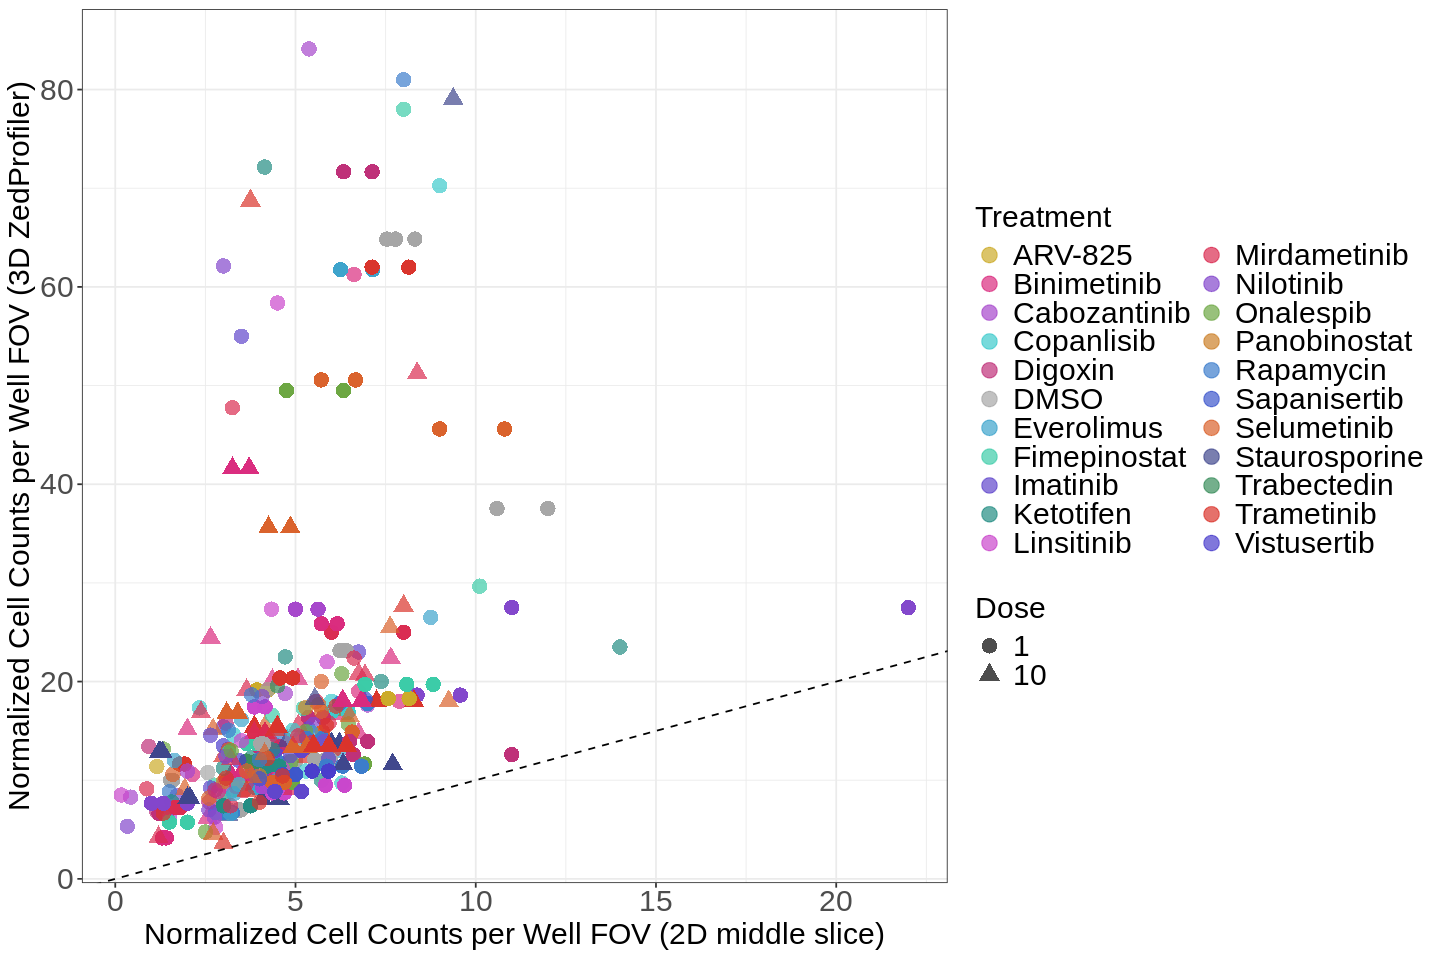

In [17]:

width <- 12
height <- 8
options(repr.plot.width = width, repr.plot.height = height)
comparison_plot_of_2D_and_3D_counts <- plot_2d_vs_3d_scatter(
    merged_df,
    x_col = "n_cells_2D_middle_slice",
    y_col = "n_cells_3D",
    color_col = "Metadata_Experiment_Treatment",
    shape_col = "Metadata_Experiment_Dose",
    color_palette = custom_treatment_palette,
    x_lab = "Normalized Cell Counts per Well FOV (2D middle slice)",
    y_lab = "Normalized Cell Counts per Well FOV (3D ZedProfiler)"
)
ggsave(
    comparison_plot_of_2D_and_3D_counts,
    filename = file.path(cell_counts_figure_path, "comparison_plot_of_2D_and_3D_counts.png"),
    width = width,
    height = height
)
comparison_plot_of_2D_and_3D_counts

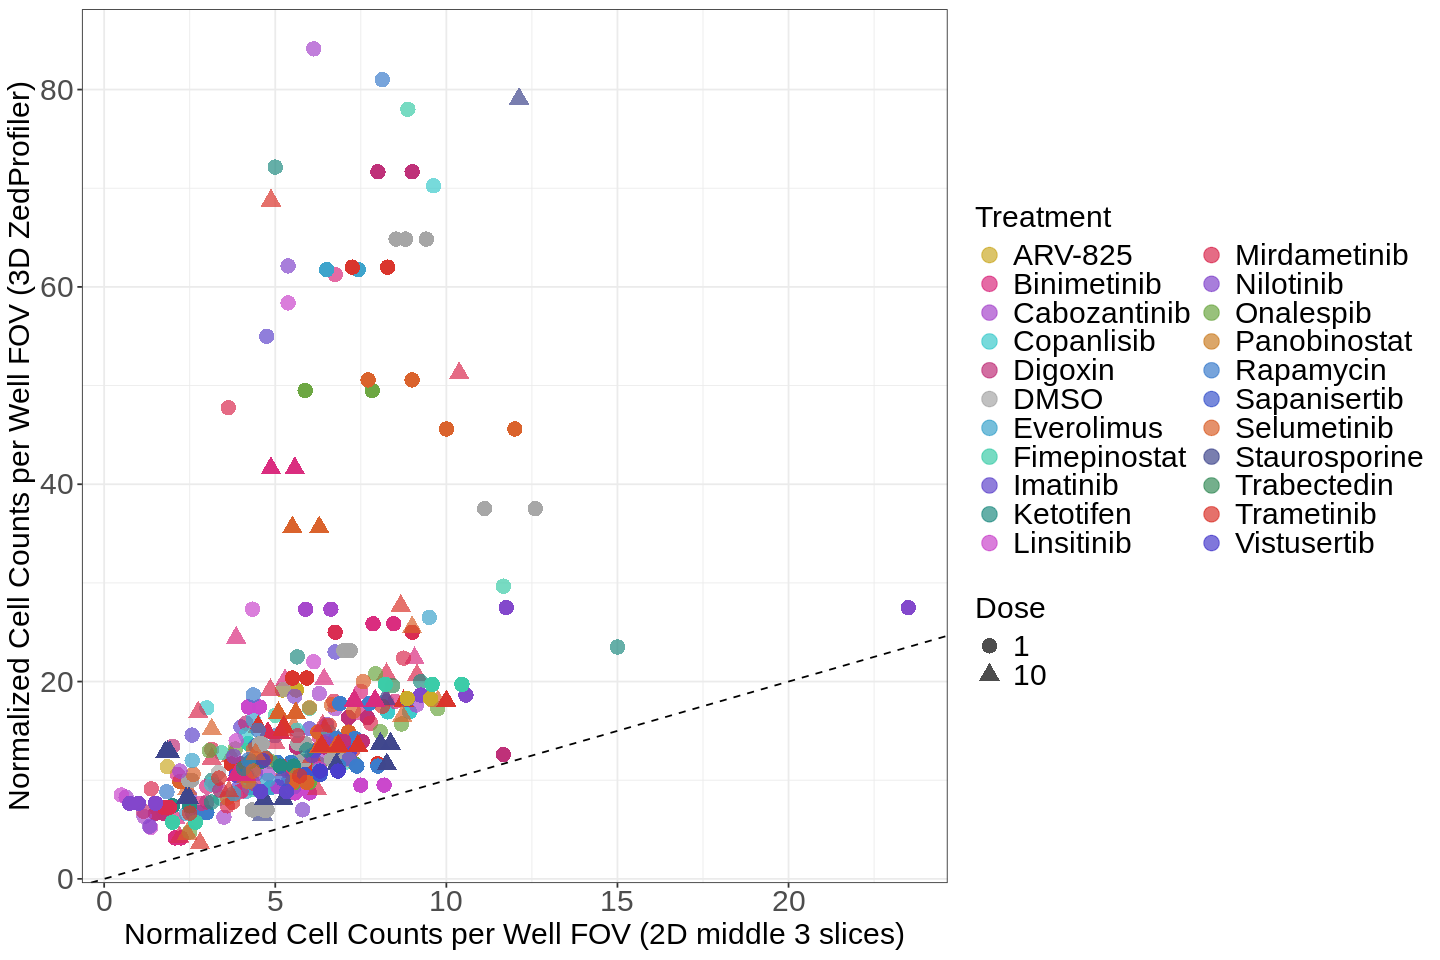

In [18]:
width <- 12
height <- 8
options(repr.plot.width = width, repr.plot.height = height)
comparison_plot_of_2D_and_3D_counts <- plot_2d_vs_3d_scatter(
    merged_df,
    x_col = "n_cells_2D_middle_n",
    y_col = "n_cells_3D",
    color_col = "Metadata_Experiment_Treatment",
    shape_col = "Metadata_Experiment_Dose",
    color_palette = custom_treatment_palette,
    x_lab = "Normalized Cell Counts per Well FOV (2D middle 3 slices)",
    y_lab = "Normalized Cell Counts per Well FOV (3D ZedProfiler)"
)
ggsave(
    comparison_plot_of_2D_and_3D_counts,
    filename = file.path(cell_counts_figure_path, "comparison_plot_of_2D_and_3D_counts_middle_n.png"),
    width = width,
    height = height
)
comparison_plot_of_2D_and_3D_counts

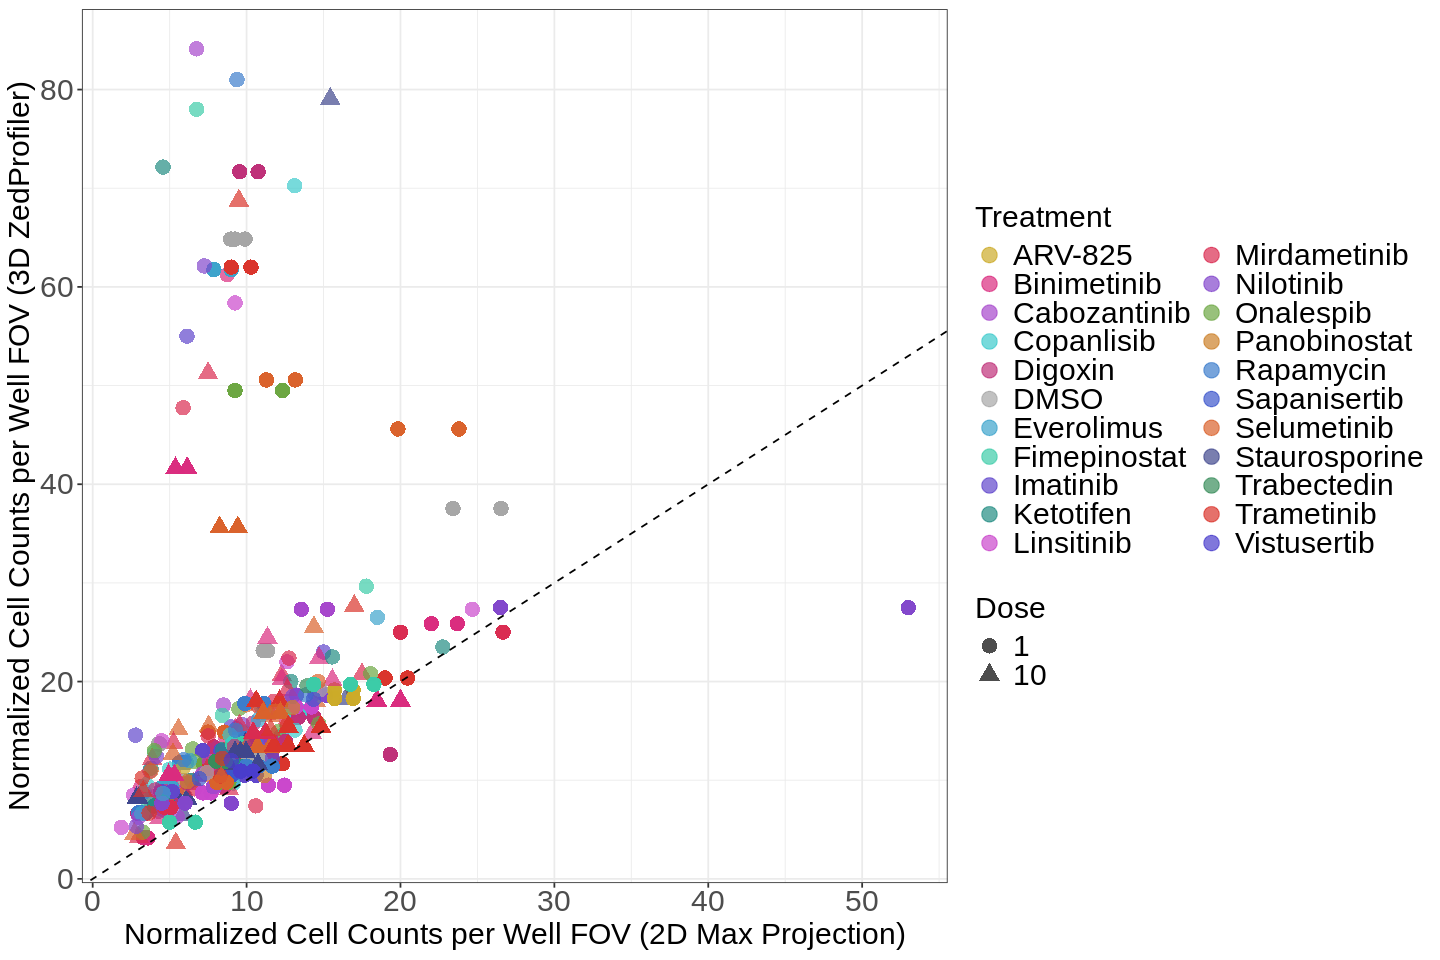

In [19]:
width <- 12
height <- 8
options(repr.plot.width = width, repr.plot.height = height)
comparison_plot_of_2D_and_3D_counts <- plot_2d_vs_3d_scatter(
    merged_df,
    x_col = "n_cells_2D_max",
    y_col = "n_cells_3D",
    color_col = "Metadata_Experiment_Treatment",
    shape_col = "Metadata_Experiment_Dose",
    color_palette = custom_treatment_palette,
    x_lab = "Normalized Cell Counts per Well FOV (2D Max Projection)",
    y_lab = "Normalized Cell Counts per Well FOV (3D ZedProfiler)"
)
ggsave(
    comparison_plot_of_2D_and_3D_counts,
    filename = file.path(cell_counts_figure_path, "comparison_plot_of_2D_and_3D_counts_max.png"),
    width = width,
    height = height
)
comparison_plot_of_2D_and_3D_counts

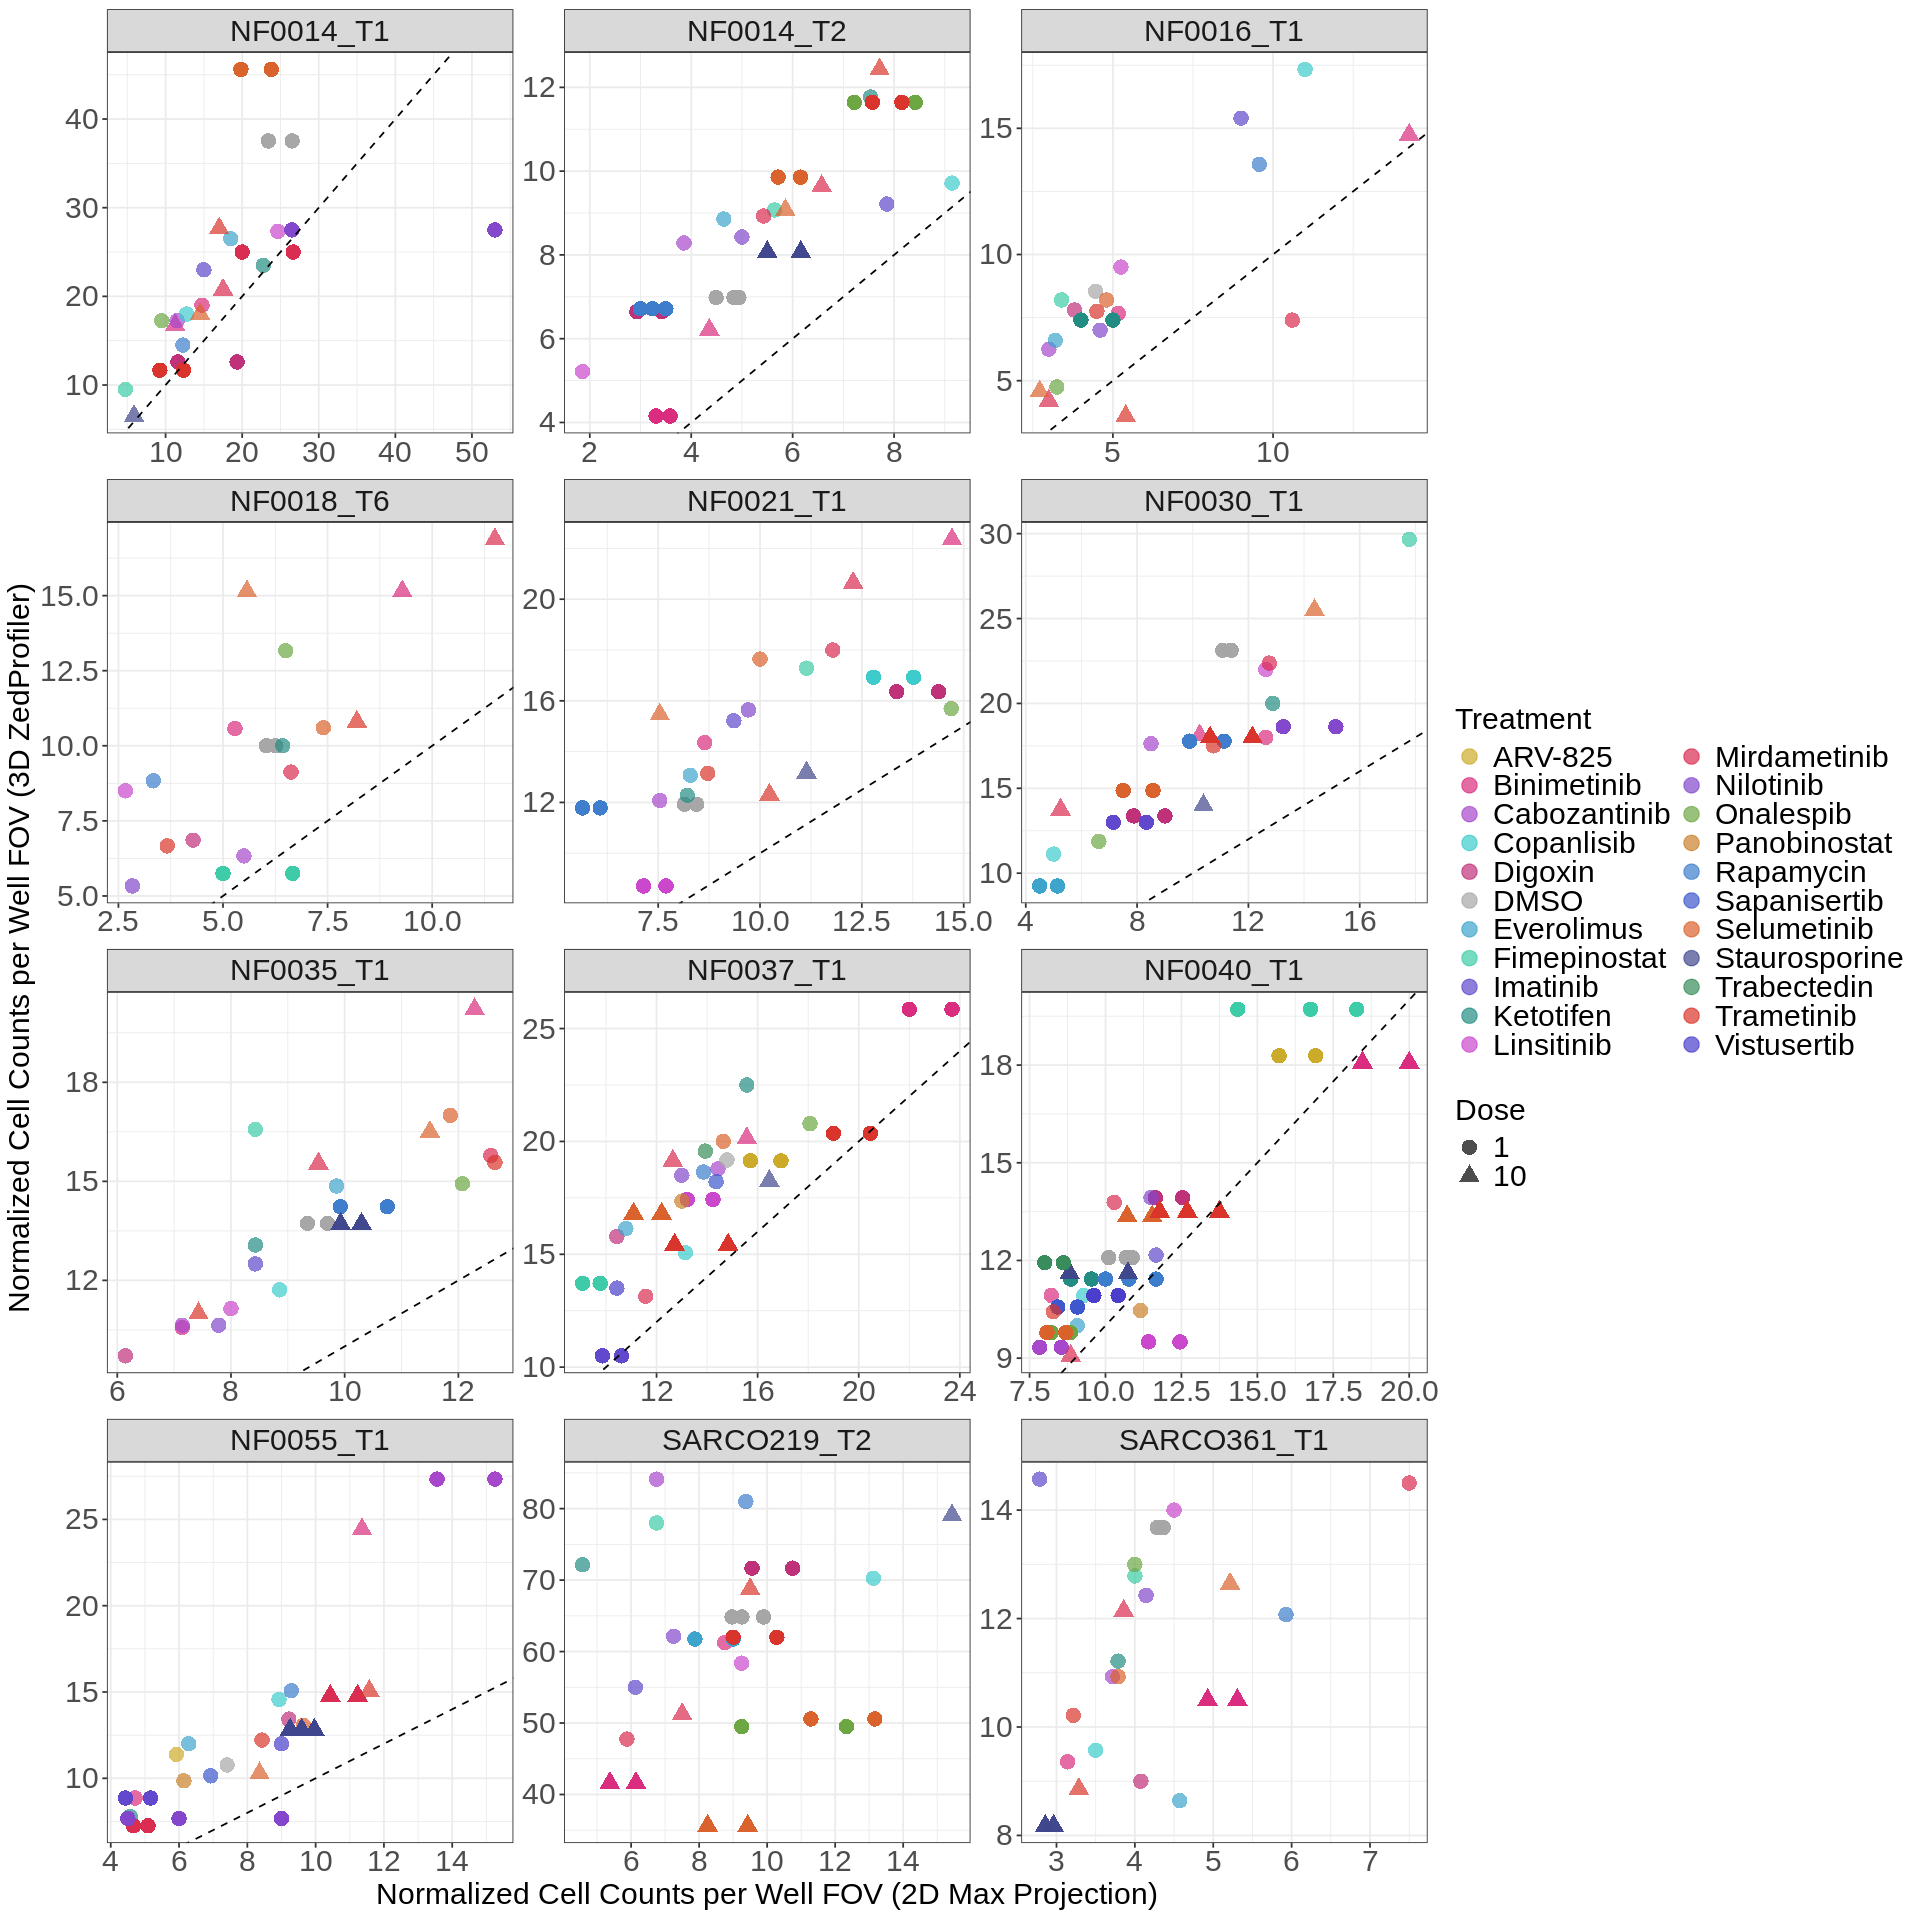

In [20]:
width <- 16
height <- 16
options(repr.plot.width = width, repr.plot.height = height)
comparison_plot_of_2D_and_3D_counts <- plot_2d_vs_3d_scatter(
    merged_df,
    x_col = "n_cells_2D_max",
    y_col = "n_cells_3D",
    color_col = "Metadata_Experiment_Treatment",
    shape_col = "Metadata_Experiment_Dose",
    color_palette = custom_treatment_palette,
    x_lab = "Normalized Cell Counts per Well FOV (2D Max Projection)",
    y_lab = "Normalized Cell Counts per Well FOV (3D ZedProfiler)",
    facet_formula = as.formula(. ~ Metadata_Biology_PatientTumor)
)
ggsave(
    comparison_plot_of_2D_and_3D_counts,
    filename = file.path(cell_counts_figure_path, "comparison_plot_of_2D_and_3D_counts_max_facet.png"),
    width = width,
    height = height
)
comparison_plot_of_2D_and_3D_counts